In [1]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\CADY\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\CADY\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [2]:
print(os.listdir("dataset"))

['customer_support_text_classification.csv', 'data_dictionary.md']


In [3]:
# Loading dataset

df = pd.read_csv("dataset/customer_support_text_classification.csv")

# First 5 rows

df.head()

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


In [4]:
# Loading dataset

df = pd.read_csv("dataset/customer_support_text_classification.csv")

# First 5 rows

df.head()

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


In [5]:
# Checking columns

print(df.columns)

Index(['ticket_id', 'channel', 'customer_message', 'sentiment_label',
       'word_count', 'urgent_flag'],
      dtype='str')


In [6]:
# Dataset shape

print("Dataset Shape:", df.shape)

# Missing values

print(df.isnull().sum())

# Sample messages

print(df['customer_message'].head())

# Average text length

df['text_length'] = df['customer_message'].apply(len)

print("Average Text Length:", df['text_length'].mean())

Dataset Shape: (1500, 6)
ticket_id           0
channel             0
customer_message    0
sentiment_label     0
word_count          0
urgent_flag         0
dtype: int64
0    I need information about the payment process. ...
1        I need information about the payment process.
2    The refund process was fast and convenient. I ...
3    My refund is still pending and this experience...
4     Please tell me how to update my account details.
Name: customer_message, dtype: str
Average Text Length: 72.75666666666666


sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


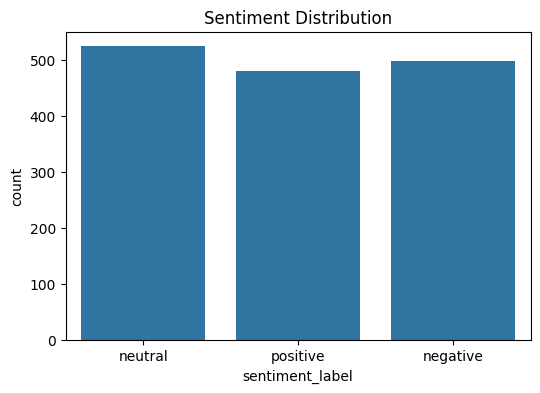

In [7]:
# Target distribution

print(df['sentiment_label'].value_counts())

# Plotting distribution

plt.figure(figsize=(6,4))

sns.countplot(x='sentiment_label', data=df)

plt.title("Sentiment Distribution")

plt.show()

In [11]:
import nltk

nltk.download('punkt')

nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\CADY\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\CADY\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [12]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\CADY\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [13]:
# Stopwords

stop_words = set(stopwords.words('english'))

# Text cleaning function

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    tokens = word_tokenize(text)

    tokens = [word for word in tokens if word not in stop_words]

    return " ".join(tokens)

# Applying cleaning

df['clean_text'] = df['customer_message'].apply(clean_text)

df[['customer_message', 'clean_text']].head()

,customer_message,clean_text
0,I need information about the payment process. ...,need information payment process ticket number...
1,I need information about the payment process.,need information payment process
2,The refund process was fast and convenient. I ...,refund process fast convenient appreciate quic...
3,My refund is still pending and this experience...,refund still pending experience frustrating ti...
4,Please tell me how to update my account details.,please tell update account details


In [14]:
# TF-IDF vectorization

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_text'])

# Target variable

y = df['sentiment_label']

print(X.shape)

(1500, 146)


In [15]:
# Splitting dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)

print(X_test.shape)

(1200, 146)
(300, 146)


In [16]:
# Logistic Regression model

model = LogisticRegression()

# Training model

model.fit(X_train, y_train)

print("Model Training Complete")

Model Training Complete


In [17]:
# Predictions

y_pred = model.predict(X_test)

# Classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



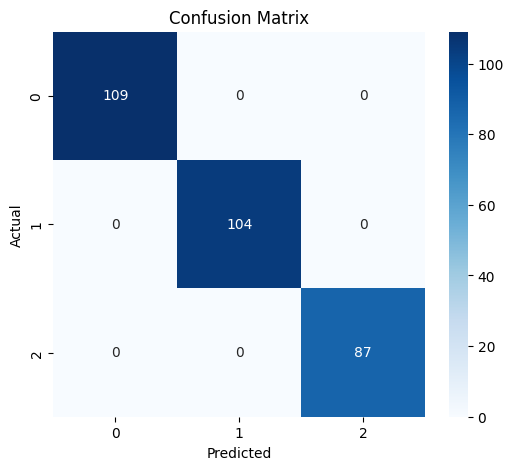

In [18]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig("results/model_evaluation.png")

plt.show()

In [19]:
# Saving sample predictions

sample_output = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

sample_output.head(10).to_csv(
    "results/sample_predictions.txt",
    index=False
)

print("Sample predictions saved")

Sample predictions saved


## Sequence Model Explanation

A sequence model like LSTM processes text word by word in sequential order.

1. Input Layer:
The text is converted into sequences of tokens.

2. Embedding Layer:
Each word is converted into dense numerical vectors.

3. LSTM Layer:
The LSTM remembers important information from previous words and helps in understanding sentence context.

4. Output Layer:
The final output layer predicts the sentiment label.

5. Loss Function:
Categorical Crossentropy can be used for classification tasks.

6. Evaluation Metric:
Accuracy is commonly used for evaluating NLP classification models.

## Attention and Transformer Reflection

RNNs struggle with long-term dependencies because they process text sequentially and may forget older information.

LSTMs improve memory using gates that help retain important information for longer sequences.

Attention mechanisms help models focus on important words while processing text.

Transformers are important because they process text more efficiently and are widely used in modern NLP systems such as ChatGPT and other Generative AI models.

In [20]:
print("NLP Project Completed Successfully")

NLP Project Completed Successfully
